# Amazon Fine Food Reviews: Sentiment vs. Star Rating, and Topic Modeling

This notebook narrates the same pipeline as `run_analysis.py`, all logic imported
from `analysis.sentiment`, `analysis.topics`, and `data.load_amazon_reviews` (no
duplicated logic here). It:

1. Loads a real, reproducible 20,000-review sample of the Amazon Fine Food Reviews
   dataset (Kaggle, `snap/amazon-fine-food-reviews`).
2. Scores each review's sentiment with VADER (lexicon-based, local, free).
3. Compares VADER's predicted sentiment against the star-rating-derived label.
4. Fits an 8-topic NMF topic model over the review text.
5. Shows topic word lists and review volume by topic.


In [1]:
import sys
from pathlib import Path

# Allow importing the project's analysis.* and data.* packages when this
# notebook is run from notebooks/ (its own directory).
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from analysis.plots import plot_sentiment_crosstab, plot_topic_volume
from analysis.sentiment import evaluate_agreement, rating_to_label, score_sentiment
from analysis.text_cleaning import strip_html
from analysis.topics import dominant_topics, fit_topic_model
from data.load_amazon_reviews import load_sample

N_TOPICS = 8

## 1. Load the real review sample

A fixed, reproducible random sample of 20,000 real Amazon Fine Food reviews
(seeded, not simulated data).

In [2]:
df = load_sample()
print(f"Loaded a real sample of {len(df):,} Amazon Fine Food reviews.")

# Real review text contains literal HTML (mostly stray `<br />` tags). Clean
# it once here, before it's used for both sentiment scoring and topic
# modeling below, so HTML markup doesn't get vectorized as if it were
# content (see analysis/text_cleaning.py).
df["Text"] = df["Text"].apply(strip_html)
df.head()

Loaded a real sample of 20,000 Amazon Fine Food reviews.


,Score,Text
0,5,Having tried a couple of other brands of glute...
1,5,My cat loves these treats. If ever I can't fin...
2,3,A little less than I expected. It tends to hav...
3,2,"First there was Frosted Mini-Wheats, in origin..."
4,5,and I want to congratulate the graphic artist ...


## 2. Score sentiment with VADER

Each review's text is scored with VADER's compound polarity score and bucketed
into `positive` / `neutral` / `negative`.

In [3]:
sentiment_df = score_sentiment(df["Text"].tolist())
df = pd.concat([df.reset_index(drop=True), sentiment_df], axis=1)
df["true_label"] = df["Score"].apply(rating_to_label)
df[["Score", "Text", "compound", "predicted_label", "true_label"]].head()

,Score,Text,compound,predicted_label,true_label
0,5,Having tried a couple of other brands of glute...,0.9684,positive,positive
1,5,My cat loves these treats. If ever I can't fin...,0.7920,positive,positive
2,3,A little less than I expected. It tends to hav...,0.4588,positive,neutral
3,2,"First there was Frosted Mini-Wheats, in origin...",0.9928,positive,negative
4,5,and I want to congratulate the graphic artist ...,0.9619,positive,positive


## 3. VADER vs. star-rating agreement

`true_label` is derived directly from the real star rating (`Score`): 4-5 stars ->
positive, 3 stars -> neutral, 1-2 stars -> negative. Because the sample is real
Amazon review data, `true_label` is heavily skewed toward positive (~5-star reviews
dominate real e-commerce review data) - the crosstab below shows the real per-class
picture, not just a single overall accuracy number.

In [4]:
agreement = evaluate_agreement(df["predicted_label"], df["true_label"])
print(
    f"VADER vs. star-rating agreement: {agreement['accuracy']:.4f} "
    f"({agreement['n_correct']}/{agreement['n']})"
)

crosstab = pd.crosstab(df["true_label"], df["predicted_label"])
crosstab

VADER vs. star-rating agreement: 0.7994 (15989/20000)


predicted_label,negative,neutral,positive
true_label,,,
negative,1178,143,1565
neutral,273,54,1192
positive,628,210,14757


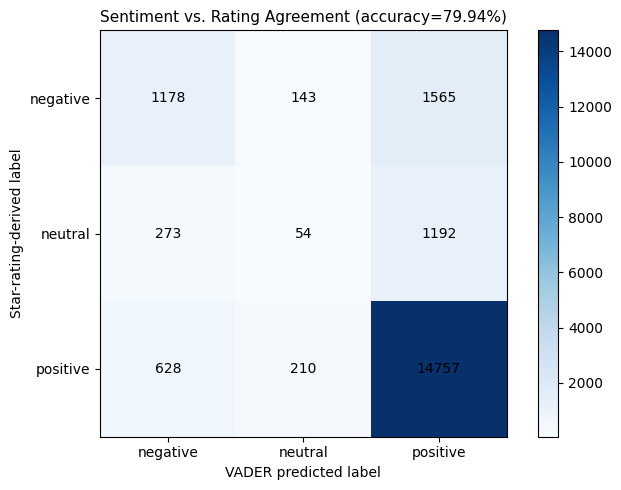

In [5]:
fig = plot_sentiment_crosstab(crosstab, agreement["accuracy"])
plt.show()

## 4. Fit an 8-topic NMF model

Topics are extracted with TF-IDF + Non-negative Matrix Factorization (NMF), a
standard, fully local/free approach to unsupervised topic modeling.

In [6]:
model, vectorizer, topic_words, W = fit_topic_model(df["Text"].tolist(), n_topics=N_TOPICS)
df["topic"] = dominant_topics(W)

topic_table = pd.DataFrame(
    {"topic": i, "top_words": ", ".join(words)} for i, words in enumerate(topic_words)
)
topic_table

,topic,top_words
0,0,"like, taste, good, flavor, just, really, water..."
1,1,"coffee, cup, strong, cups, bold, roast, keurig..."
2,2,"tea, green, teas, bags, drink, black, stash, i..."
3,3,"food, cat, cats, eat, dry, canned, foods, dog,..."
4,4,"product, great, price, amazon, order, store, b..."
5,5,"dog, treats, dogs, loves, treat, love, trainin..."
6,6,"chips, salt, bag, potato, chip, snack, love, k..."
7,7,"chocolate, cookies, free, bars, gluten, love, ..."


## 5. Review volume by topic

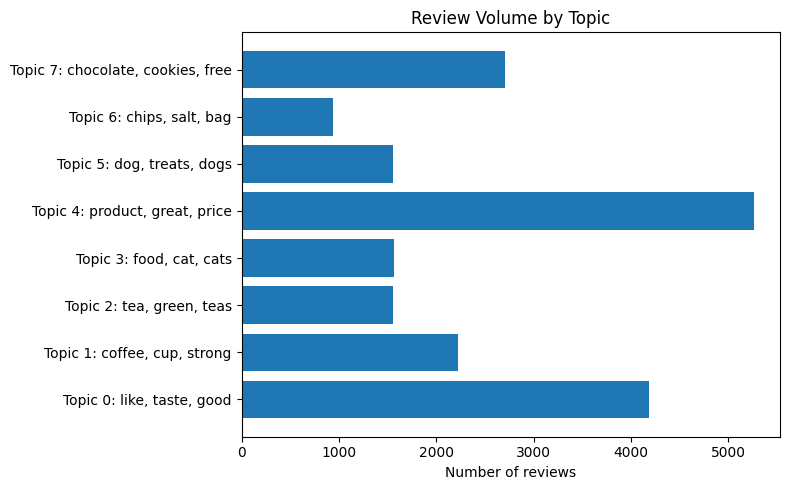

topic
0    4187
1    2219
2    1559
3    1563
4    5268
5    1557
6     942
7    2705
Name: count, dtype: int64

In [7]:
topic_sizes = df["topic"].value_counts().sort_index()
fig2 = plot_topic_volume(topic_sizes, topic_words)
plt.show()

topic_sizes

## Summary

On this real 20,000-review sample of Amazon Fine Food Reviews, VADER's predicted
sentiment agreed with the star-rating-derived label **79.94% of the time
(15,989 / 20,000)**. Agreement is much stronger on the positive class (14,757 of
15,595 true-positive reviews correctly predicted positive) than on the neutral
class, which VADER rarely predicts at all (only 54 of 1,519 true-neutral reviews
were predicted neutral) - expected given the real class imbalance in Amazon
reviews (~78% of this sample is star-rating-positive, per the crosstab above) and
because VADER's compound score rarely lands in the narrow neutral band for real
review text.

Review text is stripped of HTML markup (mostly stray `<br />` tags, present in
about a quarter of this sample) before both sentiment scoring and topic
modeling - without this cleaning step, the topic model previously produced a
whole "topic" that was really just the HTML artifact "br", not a real theme.

The most common topic found by the 8-topic NMF model is **Topic 4** (top words:
*product, great, price, amazon, order, store, buy, time, shipping, stores*),
covering 5,268 of 20,000 reviews (~26.3%) - general purchase-experience/value
reviews, distinct from the more specific product-category topics (coffee, tea,
pet food/treats, dog treats, chips/snacks, chocolate/cookies).